# 2. Stress Relaxation

A stress-relaxation experiment imposes an approximately constant strain and measures the stress required to maintain it. The response is summarized by the **relaxation modulus** $E_r(t)$.

## Learning outcomes

- derive relaxation responses from constitutive equations;
- distinguish relaxation time from creep retardation time;
- interpret a Prony series as a discrete spectrum of relaxation modes;
- compare candidate model classes using fitted residuals.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({"figure.figsize": (7.0, 4.4), "axes.grid": True})


## 2.1 Step-strain protocol

The imposed strain is

$$
\epsilon(t)=\epsilon_0 H(t).
$$

For $t>0$, the relaxation modulus is

$$
E_r(t)=\frac{\sigma(t)}{\epsilon_0}.
$$

This definition resembles $J(t)=\epsilon(t)/\sigma_0$, but the two functions come from different experiments. In general, $E_r(t)\neq 1/J(t)$ at finite time.

For a Maxwell element,

$$
\dot\epsilon=\frac{\dot\sigma}{E}+\frac{\sigma}{\eta}.
$$

After the strain step, $\dot\epsilon=0$, so

$$
\dot\sigma+\frac{1}{\tau_r}\sigma=0,
\qquad
\tau_r=\frac{\eta}{E}.
$$

The relaxation modulus is therefore $E_r(t)=E e^{-t/\tau_r}$.


## 2.2 Standard linear solid

A standard linear solid retains a nonzero equilibrium stiffness:

$$
E_r(t)=E_\infty+(E_0-E_\infty)e^{-t/\tau_r}.
$$

Here $E_0=E_r(0^+)$ is the instantaneous modulus and $E_\infty=E_r(\infty)$ is the equilibrium modulus. Passivity requires $E_0>E_\infty>0$ and $\tau_r>0$.

An ideal Kelvin--Voigt model is problematic under a mathematical step strain: the dashpot produces an impulsive stress at $t=0$. Real test machines apply a finite strain ramp, which regularizes the response. This is a reminder that the loading protocol is part of the model.


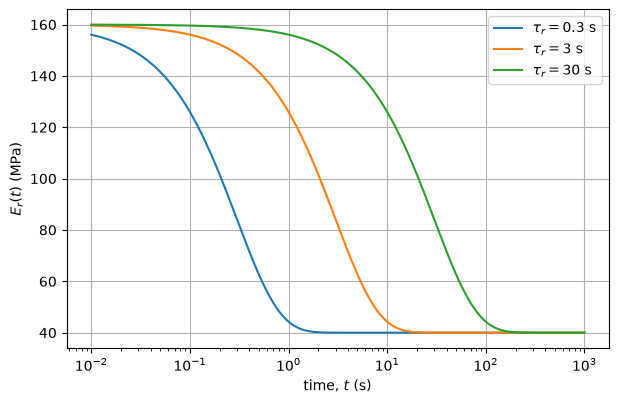

In [2]:
def E_relax_sls(t, Einf, E_mode, tau):
    t = np.asarray(t, dtype=float)
    return Einf + E_mode * np.exp(-t / tau)

t = np.geomspace(1e-2, 1e3, 600)
fig, ax = plt.subplots()
for tau in (0.3, 3.0, 30.0):
    ax.plot(t, E_relax_sls(t, Einf=40.0, E_mode=120.0, tau=tau),
            label=fr"$\tau_r={tau:g}$ s")
ax.set_xscale("log")
ax.set(xlabel="time, $t$ (s)", ylabel="$E_r(t)$ (MPa)")
ax.legend()
plt.show()


The characteristic time shifts the transition along the logarithmic time axis without changing either limiting modulus. At $t=\tau_r$, the relaxing part of the modulus has fallen to $e^{-1}$ of its initial value.

## 2.3 Generalized Maxwell model and a discrete relaxation spectrum

Many materials relax over more than one decade in time. A generalized Maxwell model represents the relaxation modulus by a Prony series,

$$
E_r(t)=E_\infty+\sum_{i=1}^{N}E_i e^{-t/\tau_i}.
$$

Each pair $(E_i,\tau_i)$ defines the strength and time of one relaxation mode. The numerical state may be written using internal stresses $q_i$:

$$
\dot q_i=-\frac{q_i}{\tau_i}+E_i\dot\epsilon,
\qquad
\sigma=E_\infty\epsilon+\sum_i q_i.
$$

The internal variables form a finite-dimensional state-space approximation to a continuous relaxation spectrum.


In [3]:
def E_relax_prony2(t, Einf, E1, tau1, E2, tau2):
    t = np.asarray(t, dtype=float)
    return Einf + E1 * np.exp(-t / tau1) + E2 * np.exp(-t / tau2)

rng = np.random.default_rng(21)
t_data = np.geomspace(0.02, 800.0, 70)
true_parameters = (35.0, 90.0, 0.8, 40.0, 80.0)
E_true = E_relax_prony2(t_data, *true_parameters)
E_measured = E_true + rng.normal(0.0, 1.2, size=t_data.size)

relaxation_data = pd.DataFrame({
    "time_s": t_data,
    "relaxation_modulus_MPa": E_measured,
})
relaxation_data.head()


,time_s,relaxation_modulus_MPa
0,0.020000,163.198421
1,0.023320,164.215535
2,0.027191,159.835238
3,0.031704,163.511093
4,0.036967,160.860559


We now fit two candidate model classes to the same data:

- a standard linear solid with one relaxation mode;
- a two-mode generalized Maxwell model.

The comparison asks whether one characteristic time is sufficient to represent the measured response.


In [4]:
popt_sls, pcov_sls = curve_fit(
    E_relax_sls,
    t_data,
    E_measured,
    p0=(30.0, 120.0, 8.0),
    bounds=(0.0, np.inf),
    maxfev=20000,
)

popt_p2, pcov_p2 = curve_fit(
    E_relax_prony2,
    t_data,
    E_measured,
    p0=(30.0, 80.0, 1.0, 45.0, 60.0),
    bounds=([0, 0, 1e-4, 0, 1e-4], [np.inf, np.inf, np.inf, np.inf, np.inf]),
    maxfev=50000,
)

residual_sls = E_measured - E_relax_sls(t_data, *popt_sls)
residual_p2 = E_measured - E_relax_prony2(t_data, *popt_p2)

comparison = pd.DataFrame({
    "model": ["standard linear solid", "two-mode Prony"],
    "number_of_parameters": [3, 5],
    "RMSE_MPa": [
        np.sqrt(np.mean(residual_sls**2)),
        np.sqrt(np.mean(residual_p2**2)),
    ],
})
comparison


,model,number_of_parameters,RMSE_MPa
0,standard linear solid,3,10.483402
1,two-mode Prony,5,1.084040


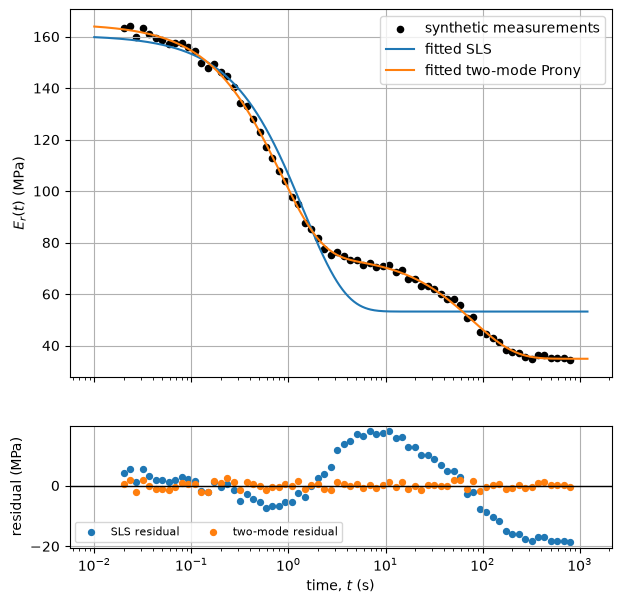

In [5]:
t_plot = np.geomspace(0.01, 1200.0, 700)
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
ax0.scatter(t_data, E_measured, s=20, color="black", label="synthetic measurements")
ax0.plot(t_plot, E_relax_sls(t_plot, *popt_sls), label="fitted SLS")
ax0.plot(t_plot, E_relax_prony2(t_plot, *popt_p2), label="fitted two-mode Prony")
ax0.set_xscale("log")
ax0.set_ylabel("$E_r(t)$ (MPa)")
ax0.legend()

ax1.axhline(0.0, color="black", linewidth=1)
ax1.scatter(t_data, residual_sls, s=18, label="SLS residual")
ax1.scatter(t_data, residual_p2, s=18, label="two-mode residual")
ax1.set_xscale("log")
ax1.set(xlabel="time, $t$ (s)", ylabel="residual (MPa)")
ax1.legend(ncol=2, fontsize=8)
plt.show()


In [6]:
parameter_table = pd.DataFrame({
    "parameter": ["Einf", "E1", "tau1", "E2", "tau2"],
    "true_value": true_parameters,
    "fitted_value": popt_p2,
    "standard_error": np.sqrt(np.diag(pcov_p2)),
})
parameter_table


,parameter,true_value,fitted_value,standard_error
0,Einf,35.0,34.877789,0.399675
1,E1,90.0,90.029856,0.477084
2,tau1,0.8,0.810383,0.012534
3,E2,40.0,40.113231,0.496423
4,tau2,80.0,79.109006,2.931244


## 2.4 Interpretation and identifiability

A smaller residual does not automatically justify an arbitrarily large number of modes. Every additional $(E_i,\tau_i)$ pair increases flexibility and can become poorly identifiable when the experiment does not cover its characteristic time.

A useful measurement window must contain times both below and above a mode's $\tau_i$. Modes far outside the measured window behave approximately like constants or linear trends and cannot be estimated independently.

## Exercises

1. Fit only the data between $0.2$ s and $200$ s. Which fitted mode changes most?
2. Plot $-\mathrm dE_r/\mathrm d\log t$. Explain why its peaks locate relaxation times.
3. Increase the noise level and repeat the two-model comparison. At what point is the second mode no longer defensible?
4. For an imposed strain $\epsilon_0=0.01$, convert the fitted relaxation modulus into stress and check the units.

The next notebook transforms the constitutive differential equation into the Laplace and frequency domains.
